# Очистка чертежа: классификация штрихов и поиск наконечников

| шаг | что делает | результат |
|---|---|---|
| 1 | загрузка, единый масштаб | `img_bgr` |
| 2 | детекция текста (PP-OCRv5 det) | `text_region` |
| 3 | бинаризация | `binary`, `fg` |
| 4 | толщина штриха через distance transform | `thickness_map`, `t_axis` |
| 5 | граф скелета, текстовые рёбра | `graph`, `is_text_edge` |
| 6 | классы толщины, KMeans **без текстовых рёбер** | `cls_img` |
| 7 | класс ребра по большинству голосов | `cls_vote` |
| 8 | удаление тонких линий и текста | `mask_thick` |
| 9 | наконечники как пики ширины | `mask_clean` |

Текст ищется не ради самого текста, а чтобы буквы не смещали распределение толщин, по которому
KMeans ставит границы классов. Поэтому граф строится **до** кластеризации: чистить выборку надо
целыми рёбрами, а не пикселями внутри прямоугольника.

Параметры задаются слайдерами. Каждая такая ячейка кончается объектом `ui_*`, результат лежит
в `ui_*.result` и распаковывается в начале следующей ячейки. Подвинул слайдер — перезапусти
ячейки ниже.

## 1. Загрузка и масштаб

Импорты и палитра классов — единственное место в ноутбуке, где что-то импортируется.

In [161]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
from ipywidgets import Checkbox, Dropdown, FloatSlider, IntSlider, interactive
from matplotlib import pyplot as plt
from scipy import ndimage as ndi
from skan import Skeleton, summarize
from skimage.morphology import h_maxima, skeletonize
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

PALETTE = [(70, 130, 255), (60, 200, 90), (255, 190, 40), (255, 70, 70), (200, 80, 255), (0, 220, 220)]

Список файлов датасета.

In [162]:
folder = Path("D:/datasets/Сравнение чертежей/Эскизы датасет")
files = sorted(folder.glob("*.jpg"))

print(f"файлов: {len(files)}")
for i, f in enumerate(files):
    print(f"[{i}] {f.stem}")

файлов: 21
[0] 1
[1] 10
[2] 11
[3] 12
[4] 13
[5] 14
[6] 15
[7] 16
[8] 17
[9] 18
[10] 19
[11] 2
[12] 20
[13] 21
[14] 3
[15] 4
[16] 5
[17] 6
[18] 7
[19] 8
[20] 9


Приводим длинную сторону к единому размеру — это **единственный** ресайз пайплайна.

Вверх бикубикой: она восстанавливает по серой кайме вокруг штриха плавный градиент, порог режет
край субпиксельно, и толщины перестают слипаться при квантовании distance transform. Вниз
`INTER_AREA`. Само по себе увеличение классы не разводит (силуэт инвариантен к умножению всех
толщин на константу) — работает именно де-квантизация.

In [163]:
def load_and_rescale(idx, target_long_side):
    path = files[idx]
    img_native = cv2.imdecode(np.fromfile(str(path), dtype=np.uint8), cv2.IMREAD_COLOR)
    nh, nw = img_native.shape[:2]

    scale = target_long_side / max(nh, nw)
    interp = cv2.INTER_CUBIC if scale > 1 else cv2.INTER_AREA
    img = cv2.resize(img_native, (round(nw * scale), round(nh * scale)), interpolation=interp)
    h, w = img.shape[:2]

    print(f"{path.name}")
    print(f"native {nw}x{nh} ({nw * nh / 1e6:.2f} MP) -> {w}x{h} ({w * h / 1e6:.2f} MP)")
    print(f"scale {scale:.4f} ({'апскейл, CUBIC' if scale > 1 else 'даунскейл, AREA'}) | min/max {img.min()}/{img.max()}")

    plt.figure(figsize=(16, 8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"[{idx}] {path.stem} — {w}x{h}")
    plt.show()
    return img, scale


ui_load = interactive(
    load_and_rescale,
    idx=Dropdown(options=[(f"[{i}] {f.stem}", i) for i, f in enumerate(files)], value=2, description="файл"),
    target_long_side=IntSlider(value=4000, min=1000, max=6000, step=100, continuous_update=False, description="длинная сторона"),
)
ui_load

interactive(children=(Dropdown(description='файл', index=2, options=(('[0] 1', 0), ('[1] 10', 1), ('[2] 11', 2…

## 2. Детекция текста

Цель — не удалить текст, а исключить его из выборки, по которой оцениваются границы классов
толщины в шаге 5. Поэтому маска может быть грубой: мы ничего не стираем, а только не учитываем.

ONNX-сессия детектора. Тяжёлая, грузится один раз.

In [207]:
import onnxruntime as ort

det_session = ort.InferenceSession("./models/PP-OCRv5_server_det_infer.onnx")
input_name = det_session.get_inputs()[0].name
print(f"вход: {input_name} | {det_session.get_inputs()[0].shape}")

вход: x | ['DynamicDimension.0', 3, 'DynamicDimension.1', 'DynamicDimension.2']


Препроцессинг. DBNet требует размер, кратный 32; добираем его **паддингом белым**, а не ресайзом,
чтобы масштаб остался ровно 1.0 и маска легла на штрихи попиксельно. Нормализация — из
`PP-OCRv5_server_det.yml`: scale 1/255, ImageNet mean/std.

In [208]:
img_bgr, scale = ui_load.result

STRIDE = 32  # требование сети, не параметр
PAD_VALUE = 255  # белый = фон чертежа


def pad_to_stride(img, stride=STRIDE, value=PAD_VALUE):
    h, w = img.shape[:2]
    ph, pw = (-h) % stride, (-w) % stride
    if ph == 0 and pw == 0:
        return img, 0, 0
    return cv2.copyMakeBorder(img, 0, ph, 0, pw, cv2.BORDER_CONSTANT, value=(value,) * 3), ph, pw


def to_blob(img):
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    return ((rgb - mean) / std).transpose(2, 0, 1)[np.newaxis, ...]


img_det, pad_h, pad_w = pad_to_stride(img_bgr)
blob = to_blob(img_det)

h, w = img_bgr.shape[:2]
dh, dw = img_det.shape[:2]
print(f"{w}x{h} -> {dw}x{dh} | добавлено строк {pad_h}, столбцов {pad_w} | h%32={dh % 32} w%32={dw % 32}")
print(f"оригинал не тронут: {np.array_equal(img_det[:h, :w], img_bgr)}")
print(f"blob {blob.shape} {blob.dtype} | min {blob.min():.3f} max {blob.max():.3f} | {blob.nbytes / 1024**2:.0f} MB")

1700x1059 -> 1728x1088 | добавлено строк 29, столбцов 28 | h%32=0 w%32=0
оригинал не тронут: True
blob (1, 3, 1088, 1728) float32 | min -2.118 max 2.640 | 22 MB


Прогон сети и обрезка полосы паддинга. Карта вероятностей `prob` совпадает с `img_bgr` попиксельно.

output (1, 1, 1088, 1728) -> карта (1059, 1700) | совпадает с img_bgr: True
вероятности: min 0.0000 max 1.0000 mean 0.0055
доля площади выше порога: >0.1: 0.525% | >0.3: 0.490% | >0.5: 0.486% | >0.7: 0.470%


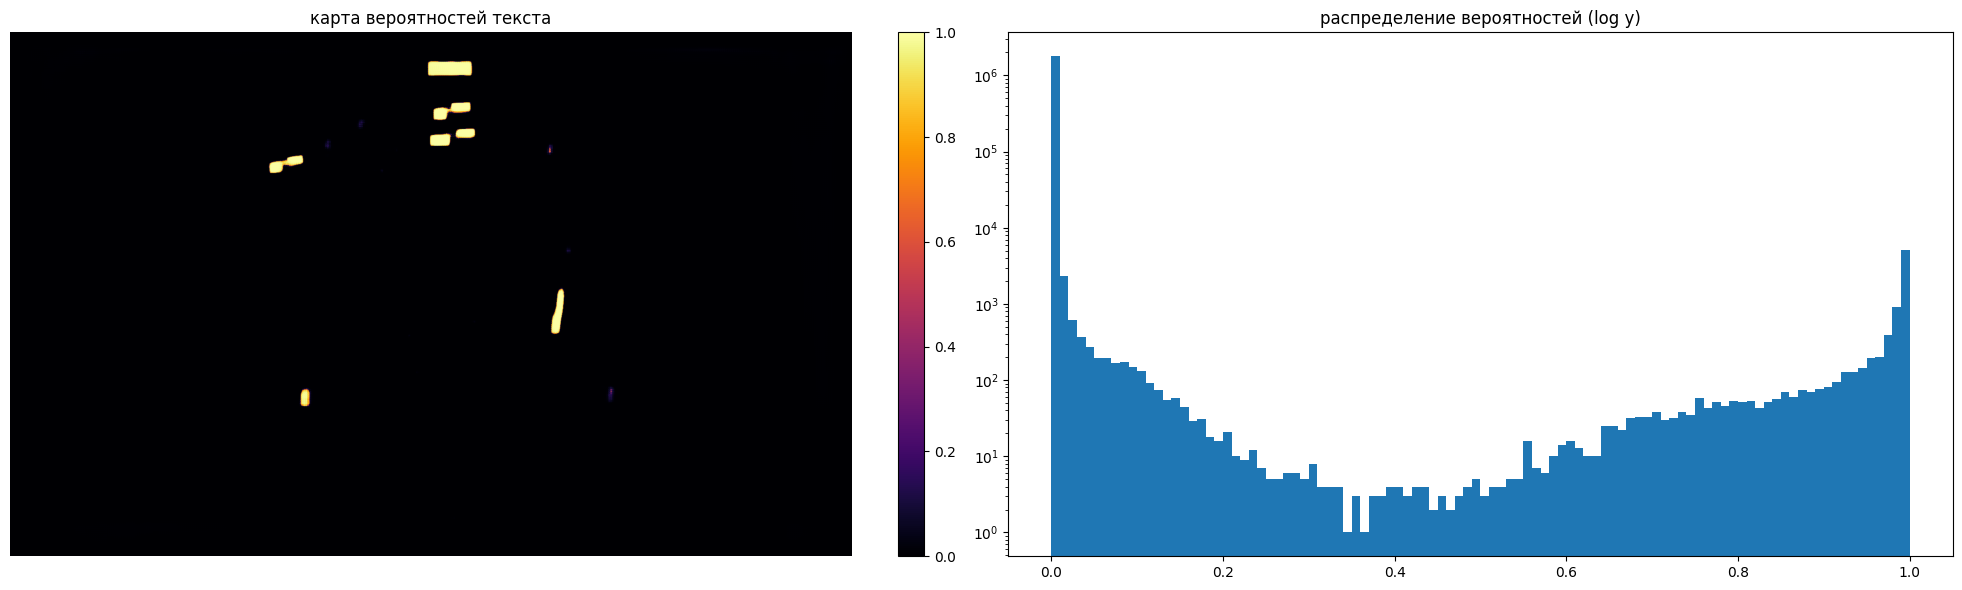

In [209]:
output = det_session.run(None, {input_name: blob})[0]
prob_full = output[0, 0]
assert prob_full.shape == img_det.shape[:2], f"выход {prob_full.shape} не совпал со входом {img_det.shape[:2]}"

prob = prob_full[:h, :w]

print(f"output {output.shape} -> карта {prob.shape} | совпадает с img_bgr: {prob.shape == (h, w)}")
print(f"вероятности: min {prob.min():.4f} max {prob.max():.4f} mean {prob.mean():.4f}")
print("доля площади выше порога: " + " | ".join(f">{t}: {(prob > t).mean() * 100:.3f}%" for t in (0.1, 0.3, 0.5, 0.7)))

fig, ax = plt.subplots(1, 2, figsize=(20, 6))
im = ax[0].imshow(prob, cmap="inferno", vmin=0, vmax=1)
ax[0].set_title("карта вероятностей текста")
ax[0].axis("off")
plt.colorbar(im, ax=ax[0], fraction=0.03)
ax[1].hist(prob.ravel(), bins=100, log=True)
ax[1].set_title("распределение вероятностей (log y)")
plt.tight_layout()
plt.show()

Кандидаты по логике `DBPostProcess`: контуры бинарной карты, `minAreaRect`, **средняя вероятность
внутри прямоугольника**. Порог `thresh` отвечает только за связность, решение принимает
`box_thresh` по этой средней. Площадь кандидата тут не участвует вообще.

In [210]:
def box_score(prob, box):
    """Средняя вероятность внутри четырёхугольника — score из DBPostProcess."""
    hh, ww = prob.shape[:2]
    b = box.copy()
    xmin, xmax = np.clip([np.floor(b[:, 0].min()), np.ceil(b[:, 0].max())], 0, ww - 1).astype(np.int32)
    ymin, ymax = np.clip([np.floor(b[:, 1].min()), np.ceil(b[:, 1].max())], 0, hh - 1).astype(np.int32)
    m = np.zeros((ymax - ymin + 1, xmax - xmin + 1), dtype=np.uint8)
    b[:, 0] -= xmin
    b[:, 1] -= ymin
    cv2.fillPoly(m, b.reshape(1, -1, 2).astype(np.int32), 1)
    return cv2.mean(prob[ymin : ymax + 1, xmin : xmax + 1], m)[0]


def db_candidates(prob, thresh, box_thresh, min_size, max_candidates=1000):
    """Только отбор кандидатов. Маска строится отдельно — чтобы отбор можно было смотреть сам по себе."""
    cnts, _ = cv2.findContours((prob > thresh).astype(np.uint8), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    rows = []
    for c in cnts[:max_candidates]:
        rect = cv2.minAreaRect(c)
        (rw, rh) = rect[1]
        area, perim = cv2.contourArea(c), cv2.arcLength(c, True)
        rows.append(
            dict(
                score=box_score(prob, cv2.boxPoints(rect)),
                sside=min(rw, rh),
                lside=max(rw, rh),
                area=area,
                perim=perim,
                fill=area / (rw * rh) if rw * rh else 0.0,
                cnt=c,
            )
        )
    df = pd.DataFrame(rows)
    if len(df):
        df["keep"] = (df.score >= box_thresh) & (df.sside >= min_size) & (df.perim > 0)
    return df, len(cnts)


def show_candidates(thresh, box_thresh, min_size):
    df, n_all = db_candidates(prob, thresh, box_thresh, min_size)
    if n_all > 1000:
        print(f"ВНИМАНИЕ: контуров {n_all}, лимит 1000 обрезал список")
    if not len(df):
        print("кандидатов нет")
        return df

    print(f"кандидатов {len(df)} | принято {int(df.keep.sum())} | отброшено {int((~df.keep).sum())}")
    print("\n5 крупнейших по площади:")
    print(df.drop(columns="cnt").sort_values("area", ascending=False).head(5).round(3).to_string())

    fig, ax = plt.subplots(1, 2, figsize=(18, 5))
    ax[0].hist(df.score, bins=40)
    ax[0].axvline(box_thresh, color="r", ls="--")
    ax[0].set_title("score кандидатов")
    ax[1].scatter(df.area, df.score, s=14, c=np.where(df.keep, "green", "red"))
    ax[1].axhline(box_thresh, color="r", ls="--")
    ax[1].set_xscale("log")
    ax[1].set_xlabel("площадь, px (log)")
    ax[1].set_ylabel("score")
    ax[1].set_title("разделяет score, а не площадь")
    plt.tight_layout()
    plt.show()
    return df


ui_cand = interactive(
    show_candidates,
    thresh=FloatSlider(value=0.3, min=0.05, max=0.9, step=0.05, continuous_update=False, description="thresh"),
    box_thresh=FloatSlider(value=0.55, min=0.1, max=0.95, step=0.05, continuous_update=False, description="box_thresh"),
    min_size=IntSlider(value=3, min=0, max=30, step=1, continuous_update=False, description="min_size"),
)
ui_cand

interactive(children=(FloatSlider(value=0.3, continuous_update=False, description='thresh', max=0.9, min=0.05,…

Маска текстовой области: контур каждого принятого ядра раздувается на `d = area·ratio/perimeter`.
Раздуваем сам контур, а не описанный прямоугольник, — форма идёт вдоль наклонных надписей и
захватывает меньше лишнего. Бери с запасом: лишний захват линии стоит дёшево, пропущенный текст — дорого.

In [211]:
df_cand = ui_cand.result
assert df_cand is not None and len(df_cand), "кандидатов нет — ослабь thresh в предыдущей ячейке"


def build_region(unclip_ratio):
    region = np.zeros((h, w), np.uint8)
    kept = df_cand[df_cand.keep]
    for c, area, perim in zip(kept.cnt, kept.area, kept.perim):
        d = int(round(area * unclip_ratio / perim))
        x, y, bw, bh = cv2.boundingRect(c)
        pad = d + 2
        x0, y0 = max(0, x - pad), max(0, y - pad)
        x1, y1 = min(w, x + bw + pad), min(h, y + bh + pad)

        sub = np.zeros((y1 - y0, x1 - x0), np.uint8)
        cv2.drawContours(sub, [c - np.array([[x0, y0]])], -1, 255, cv2.FILLED)
        if d > 0:
            dist = cv2.distanceTransform(np.where(sub > 0, 0, 255).astype(np.uint8), cv2.DIST_L2, cv2.DIST_MASK_PRECISE)
            sub = np.where((dist <= d) | (sub > 0), 255, 0).astype(np.uint8)
        region[y0:y1, x0:x1] = np.maximum(region[y0:y1, x0:x1], sub)

    core_u8 = np.zeros((h, w), np.uint8)
    for c in kept.cnt:
        cv2.drawContours(core_u8, [c], -1, 255, cv2.FILLED)
    core_px = core_u8 > 0

    print(f"принятых ядер {len(kept)} | ядро {core_px.mean() * 100:.3f}% -> область {(region > 0).mean() * 100:.3f}%")

    overlay = img_bgr.copy()
    overlay[region > 0] = (0, 0, 255)
    overlay[core_px] = (0, 140, 255)
    blend = cv2.addWeighted(overlay, 0.45, img_bgr, 0.55, 0)

    plt.figure(figsize=(18, 10))
    plt.imshow(cv2.cvtColor(blend, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"оранжевое — ядро сети, красное — раздутие на unclip {unclip_ratio}")
    plt.show()
    return region > 0


ui_region = interactive(
    build_region,
    unclip_ratio=FloatSlider(value=1.5, min=0.0, max=4.0, step=0.1, continuous_update=False, description="unclip"),
)
ui_region

interactive(children=(FloatSlider(value=1.5, continuous_update=False, description='unclip', max=4.0), Output()…

## 3. Бинаризация

Штрих тёмный на светлом, отсюда `THRESH_BINARY_INV`. Размытие гасит зерно JPEG: без него тонкие
линии рвутся, а разрыв плодит ложные концы в графе. Otsu ставит порог по гистограмме сам;
ручной режим нужен на сканах с неровным фоном.

In [ ]:
text_region = ui_region.result

gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)


def binarize(blur_k, use_otsu, manual_thresh):
    blurred = cv2.GaussianBlur(gray, (blur_k, blur_k), 0)
    normalized = cv2.normalize(blurred, None, 0, 255, cv2.NORM_MINMAX)
    if use_otsu:
        used, binary = cv2.threshold(normalized, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    else:
        used, binary = cv2.threshold(normalized, manual_thresh, 255, cv2.THRESH_BINARY_INV)
    fg = binary > 0

    n_cc = cv2.connectedComponents(binary, connectivity=8)[0] - 1
    print(f"порог: {used:.0f} ({'Otsu' if use_otsu else 'вручную'}) | блюр {blur_k}x{blur_k}")
    print(f"передний план {int(fg.sum())} px ({fg.mean() * 100:.2f}%) | связных компонент {n_cc}")

    plt.figure(figsize=(16, 8))
    plt.imshow(binary, cmap="gray")
    plt.axis("off")
    plt.title(f"бинаризация, порог {used:.0f}")
    plt.show()
    return binary, fg


ui_binary = interactive(
    binarize,
    blur_k=IntSlider(value=5, min=1, max=15, step=2, continuous_update=False, description="блюр"),
    use_otsu=Checkbox(value=True, description="Otsu"),
    manual_thresh=IntSlider(value=200, min=50, max=250, step=5, continuous_update=False, description="порог"),
)
ui_binary

interactive(children=(IntSlider(value=5, continuous_update=False, description='блюр', max=15, min=1, step=2), …

## 4. Толщина штриха

`distanceTransform` даёт расстояние до фона, то есть половину локальной ширины. Значения снимаем
**только с медиальной оси**: на краях штриха оценка занижена по построению и смазывает гистограмму.
Параметров нет; ячейка дорогая, поэтому и вынесена отдельно от подбора классов.

пикселей скелета 10542 | из них в текстовой области 1056 (10.0%)
толщина на оси, px — min/median/max: 2.00 / 5.00 / 14.00
перцентили (10/25/50/75/90/99): [np.float64(2.0), np.float64(2.0), np.float64(5.0), np.float64(5.0), np.float64(5.0), np.float64(11.0)]


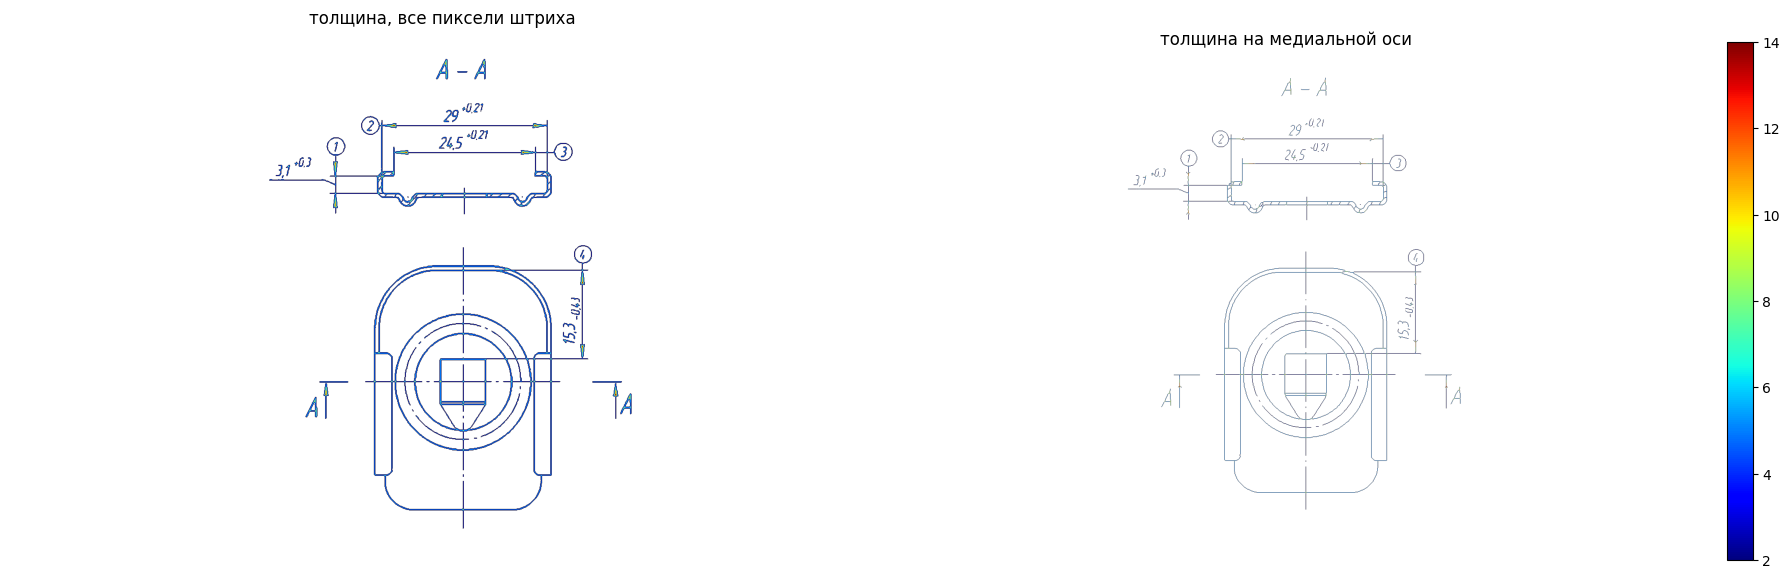

In [213]:
binary, fg = ui_binary.result

skel = skeletonize(fg)
dist = cv2.distanceTransform(binary, cv2.DIST_L1, cv2.DIST_MASK_PRECISE)
thickness_map = 3 * dist - 1  # ширина штриха в px; множитель влияет только на шкалу
t_axis = thickness_map[skel]

in_text = skel & text_region
print(f"пикселей скелета {int(skel.sum())} | из них в текстовой области {int(in_text.sum())} ({in_text.sum() / max(skel.sum(), 1) * 100:.1f}%)")
print(f"толщина на оси, px — min/median/max: {t_axis.min():.2f} / {np.median(t_axis):.2f} / {t_axis.max():.2f}")
print("перцентили (10/25/50/75/90/99):", [round(v, 2) for v in np.percentile(t_axis, [10, 25, 50, 75, 90, 99])])

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
ax[0].imshow(np.where(fg, thickness_map, np.nan), cmap="jet")
ax[0].set_title("толщина, все пиксели штриха")
ax[0].axis("off")
im = ax[1].imshow(np.where(skel, thickness_map, np.nan), cmap="jet")
ax[1].set_title("толщина на медиальной оси")
ax[1].axis("off")
plt.colorbar(im, ax=ax[1], fraction=0.03)
plt.tight_layout()
plt.show()

## 5. Граф скелета и текстовые рёбра

`skan` режет скелет на рёбра — участки между узлами ветвления. Граф не зависит от классов
толщины, поэтому строится **до** кластеризации: его рёбра нужны уже на этапе отбора выборки.

Здесь же считается матрица `P` (какие пиксели скелета принадлежат какому ребру) и разлив номера
ребра с оси на тело штриха. Параметров нет, ячейка дорогая.

In [214]:
sk_val = np.where(skel, thickness_map, 0).astype(np.float32)
assert sk_val[skel].min() > 0, "на скелете есть нули — skan срежет эти пиксели"

graph = Skeleton(sk_val)
br = summarize(graph, separator="_")
coords = graph.coordinates.astype(int)

edge_of_sk = np.full(skel.shape, -1, dtype=np.int32)
for i in range(graph.n_paths):
    c = graph.path_coordinates(i).astype(int)
    edge_of_sk[c[:, 0], c[:, 1]] = i

P = graph.paths[:, : coords.shape[0]].copy()
P.data[:] = 1  # индикатор «пиксель принадлежит ребру»
edge_len = np.asarray(P.sum(1)).ravel()  # длина ребра в пикселях скелета

# каждый пиксель фона приписан к ближайшему пикселю скелета, а значит к ребру
_, lbl = cv2.distanceTransformWithLabels(
    (~skel).astype(np.uint8), cv2.DIST_L2, cv2.DIST_MASK_PRECISE, labelType=cv2.DIST_LABEL_PIXEL
)
lut = np.full(int(lbl.max()) + 1, -1, dtype=np.int32)
lut[lbl[skel]] = edge_of_sk[skel]
edge_img = lut[lbl]

TYPES = {0: "конец-конец", 1: "узел-конец", 2: "узел-узел", 3: "цикл"}
br["type_name"] = br["branch_type"].map(TYPES)
n_nodes = pd.unique(br[["node_id_src", "node_id_dst"]].to_numpy().ravel()).size

print(f"рёбер {graph.n_paths} | узлов {n_nodes} | подграфов {br['skeleton_id'].nunique()}")
print(
    br.groupby("type_name")
    .agg(n=("branch_distance", "size"), len_med=("branch_distance", "median"),
         len_max=("branch_distance", "max"), thick_med=("mean_pixel_value", "median"))
    .round(2)
    .to_string()
)

рёбер 378 | узлов 363 | подграфов 58
               n  len_med  len_max  thick_med
type_name                                    
конец-конец   39     6.00   124.61       2.76
узел-конец   102    11.00   132.31       4.43
узел-узел    232    16.49   302.24       5.05
цикл           5   113.15   113.98       2.86


Текстовость ребра: доля его пикселей, попавших в `text_region`. У буквы она около единицы, у
размерной линии, которая лишь проходит сквозь область, — мала, потому что линия длинная.

Именно этот признак, а не попиксельная маска, чистит выборку для KMeans в следующем шаге: линия,
пересекающая область с цифрами, остаётся в выборке целиком, а буква выбрасывается целиком, даже
если её хвост торчит наружу.

In [215]:
px_in_text = text_region[coords[:, 0], coords[:, 1]].astype(np.float32)
cover = (P @ px_in_text) / np.clip(edge_len, 1, None)


def mark_text_edges(min_cover):
    is_text = cover >= min_cover
    ambiguous = int(((cover > 0.2) & (cover < 0.8)).sum())

    print(f"рёбер текстовых {int(is_text.sum())} из {len(cover)} | их длина {edge_len[is_text].sum() / edge_len.sum() * 100:.1f}% скелета")
    print(f"cover: медиана {np.median(cover):.3f} | ровно 0: {int((cover == 0).sum())} | ровно 1: {int((cover >= 0.999).sum())}")
    print(f"спорных рёбер (0.2 < cover < 0.8): {ambiguous} — чем меньше, тем чище разделение")
    if is_text.any():
        print(f"текстовые рёбра: длина медиана {np.median(edge_len[is_text]):.0f} px, толщина медиана {np.median(br.mean_pixel_value[is_text]):.2f} px")
    if (~is_text).any():
        print(f"остальные рёбра: длина медиана {np.median(edge_len[~is_text]):.0f} px, толщина медиана {np.median(br.mean_pixel_value[~is_text]):.2f} px")

    vis = np.zeros((*binary.shape, 3), dtype=np.uint8)
    vis[fg] = (70, 70, 70)
    text_px = (edge_img >= 0) & is_text[np.clip(edge_img, 0, None)] & fg
    vis[text_px] = (255, 70, 70)
    vis[text_region & ~fg] = (40, 40, 90)

    fig, ax = plt.subplots(1, 2, figsize=(18, 4))
    ax[0].hist(cover, bins=50, log=True)
    ax[0].axvline(min_cover, color="r", ls="--")
    ax[0].set_xlabel("доля ребра внутри text_region")
    ax[0].set_title("разделяются ли буквы и линии")
    ax[1].scatter(edge_len, cover, s=12, c=np.where(is_text, "red", "gray"))
    ax[1].axhline(min_cover, color="r", ls="--")
    ax[1].set_xscale("log")
    ax[1].set_xlabel("длина ребра, px (log)")
    ax[1].set_ylabel("cover")
    ax[1].set_title("длинное ребро с высоким cover — повод посмотреть глазами")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(18, 9))
    plt.imshow(vis)
    plt.axis("off")
    plt.title(f"красное — рёбра, помеченные текстом (cover >= {min_cover}); синее — область без штриха")
    plt.show()
    return is_text


ui_text_edges = interactive(
    mark_text_edges,
    min_cover=FloatSlider(value=0.8, min=0.1, max=1.0, step=0.05, continuous_update=False, description="мин cover"),
)
ui_text_edges

interactive(children=(FloatSlider(value=0.8, continuous_update=False, description='мин cover', max=1.0, min=0.…

## 6. Классы толщины

Границы ставит KMeans по гистограмме толщин на медиальной оси. Буквы дают собственный пик между
«тонкими» и «основным штрихом», из-за него граница уезжает, и пологие дуги перескакивают в
соседний класс. Поэтому из выборки выбрасываются пиксели, чьё **ребро** помечено текстом;
применяются же границы ко всему изображению.

Число классов выбирается по излому `inertia` и silhouette, а не назначается. Сними галку и
сравни таблицы: если без текста оптимальное `k` изменилось, эффект подтверждён.

In [216]:
is_text_edge = ui_text_edges.result

# пиксель оси считается текстовым, если текстовым помечено его ребро
text_axis = skel & (edge_of_sk >= 0) & is_text_edge[np.clip(edge_of_sk, 0, None)]
print(f"пикселей оси всего {int(skel.sum())} | текстовых {int(text_axis.sum())} ({text_axis.sum() / skel.sum() * 100:.1f}%)")

_km_cache = {}


def fit_models(exclude_text):
    """KMeans по k=2..6. Кэш, чтобы слайдер k не пересчитывал всё; ключ учитывает набор текстовых рёбер."""
    key = (exclude_text, int(is_text_edge.sum()))
    if key not in _km_cache:
        vals = thickness_map[skel & ~text_axis] if exclude_text else thickness_map[skel]
        X = vals.reshape(-1, 1).astype(np.float64)
        rng = np.random.default_rng(0)
        idx = rng.choice(len(X), size=min(5000, len(X)), replace=False)  # silhouette квадратичен
        out = {}
        for kk in range(2, 7):
            m = KMeans(n_clusters=kk, n_init=10, random_state=0).fit(X)
            out[kk] = (m, silhouette_score(X[idx], m.predict(X[idx])))
        _km_cache[key] = (out, vals)
    return _km_cache[key]


def choose_classes(k, exclude_text):
    models, vals = fit_models(exclude_text)
    print(f"выборка: {len(vals)} px оси ({'без текстовых рёбер' if exclude_text else 'весь скелет'})")
    print(f"{'k':>2} | {'inertia':>14} | {'silhouette':>10} | центры, px")
    for kk, (m, sil) in models.items():
        mark = " <-" if kk == k else ""
        print(f"{kk:2d} | {m.inertia_:14.1f} | {sil:10.3f} | {np.sort(m.cluster_centers_.ravel()).round(2)}{mark}")

    centers = np.sort(models[k][0].cluster_centers_.ravel())
    bounds = (centers[:-1] + centers[1:]) / 2
    cls_img = np.digitize(thickness_map, bounds)

    print(f"\nграницы, px: {bounds.round(2)}")
    for i in range(k):
        m = fg & (cls_img == i)
        print(f"класс {i}: центр {centers[i]:5.2f} px | пикселей {int(m.sum()):8d} ({m.sum() / fg.sum() * 100:5.1f}%)")

    t_clean = thickness_map[skel & ~text_axis]
    t_text = thickness_map[text_axis]
    plt.figure(figsize=(16, 4))
    plt.hist(t_clean, bins=120, alpha=0.75, label=f"линии ({len(t_clean)} px)", density=True)
    if len(t_text):
        plt.hist(t_text, bins=120, alpha=0.55, label=f"текстовые рёбра ({len(t_text)} px)", density=True)
    for b in bounds:
        plt.axvline(b, color="r", ls="--")
    plt.xlim(0, np.percentile(t_axis, 99))
    plt.xlabel("толщина на оси, px")
    plt.legend()
    plt.title("есть ли у текста свой пик (красное — границы классов)")
    plt.show()

    vis = np.zeros((*binary.shape, 3), dtype=np.uint8)
    for i in range(k):
        vis[fg & (cls_img == i)] = PALETTE[i]
    plt.figure(figsize=(18, 9))
    plt.imshow(vis)
    plt.axis("off")
    plt.title("попиксельные классы: " + ", ".join(f"{i} = {centers[i]:.1f}px" for i in range(k)))
    plt.show()
    return k, bounds, cls_img


ui_cls = interactive(
    choose_classes,
    k=IntSlider(value=3, min=2, max=6, step=1, continuous_update=False, description="классов"),
    exclude_text=Checkbox(value=True, description="без текста"),
)
ui_cls

пикселей оси всего 10542 | текстовых 912 (8.7%)


interactive(children=(IntSlider(value=3, continuous_update=False, description='классов', max=6, min=2), Checkb…

## 7. Класс ребра по большинству голосов

Попиксельная толщина врёт в узлах пересечений и на пологих дугах: там в штрих вписывается круг
большего радиуса, и одна линия красится в разные классы. Класс назначается ребру целиком — по
моде попиксельных классов на нём.

чистота голосования, медиана 0.800 | смешанных рёбер (purity < 0.9): 248
пикселей сменили класс: 14488 (47.25%)
класс 0: рёбер   148 | пикселей    20446 ->     8901
класс 1: рёбер   174 | пикселей     9131 ->    19853
класс 2: рёбер    56 | пикселей     1084 ->     1897


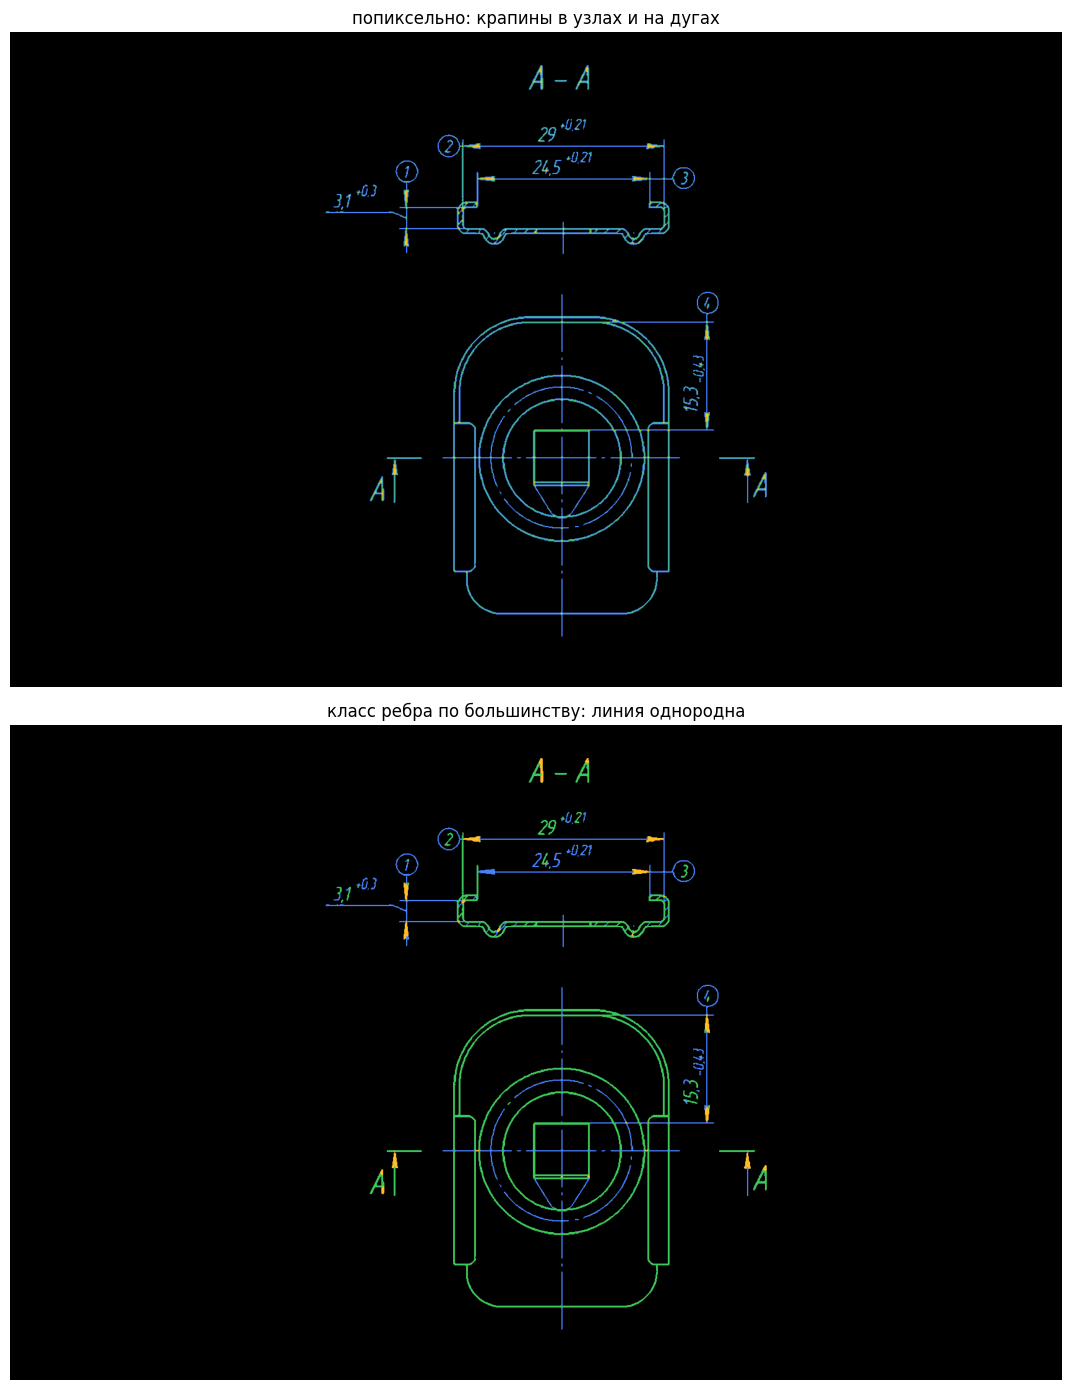

In [217]:
k, bounds, cls_img = ui_cls.result

px_cls = cls_img[coords[:, 0], coords[:, 1]]
votes = np.column_stack([P @ (px_cls == c).astype(np.float32) for c in range(k)])
edge_cls = votes.argmax(1)
purity = votes.max(1) / votes.sum(1).clip(min=1)

cls_vote = np.where(edge_img >= 0, edge_cls[np.clip(edge_img, 0, None)], -1)

print(f"чистота голосования, медиана {np.median(purity):.3f} | смешанных рёбер (purity < 0.9): {int((purity < 0.9).sum())}")
print(f"пикселей сменили класс: {int((cls_vote != cls_img)[fg].sum())} ({(cls_vote != cls_img)[fg].mean() * 100:.2f}%)")
for c in range(k):
    print(f"класс {c}: рёбер {int((edge_cls == c).sum()):5d} | пикселей {int((cls_img[fg] == c).sum()):8d} -> {int((cls_vote[fg] == c).sum()):8d}")

vis_old = np.zeros((*binary.shape, 3), dtype=np.uint8)
vis_new = np.zeros((*binary.shape, 3), dtype=np.uint8)
for c in range(k):
    vis_old[fg & (cls_img == c)] = PALETTE[c]
    vis_new[fg & (cls_vote == c)] = PALETTE[c]

fig, ax = plt.subplots(2, 1, figsize=(18, 14))
ax[0].imshow(vis_old)
ax[0].set_title("попиксельно: крапины в узлах и на дугах")
ax[0].axis("off")
ax[1].imshow(vis_new)
ax[1].set_title("класс ребра по большинству: линия однородна")
ax[1].axis("off")
plt.tight_layout()
plt.show()

## 8. Удаление тонких линий и текста

По разбиению Вороного удалять нельзя: там, где тонкая линия упирается в толстую, часть тела
толстой оказывается ближе к чужому скелету, и в контуре выедается выемка. Восстанавливаем
оставляемые штрихи из их же оси — штрих есть объединение максимальных вписанных кругов с
центрами на медиальной оси.

Оба отсева идут одним проходом: ребро выбрасывается, если оно тоньше порога **или** помечено
текстом. Линия, проходящая сквозь текстовую область, при этом уцелеет — она осталась в
`sk_keep`, и её тело восстановится по своим же кругам.

In [206]:
is_text_edge = ui_text_edges.result

dist_l2 = cv2.distanceTransform(binary, cv2.DIST_L2, cv2.DIST_MASK_PRECISE)  # радиус вписанного круга


def drop_edges(keep_from, drop_text):
    thin_edge = edge_cls < keep_from
    text_edge = is_text_edge if drop_text else np.zeros_like(is_text_edge)
    keep_edge = ~(thin_edge | text_edge)

    sk_keep = skel & (edge_of_sk >= 0) & keep_edge[np.clip(edge_of_sk, 0, None)]

    D, lbl_k = cv2.distanceTransformWithLabels(
        (~sk_keep).astype(np.uint8), cv2.DIST_L2, cv2.DIST_MASK_PRECISE, labelType=cv2.DIST_LABEL_PIXEL
    )
    rad = np.zeros(int(lbl_k.max()) + 1, dtype=np.float32)
    rad[lbl_k[sk_keep]] = dist_l2[sk_keep]

    mask_thick = fg & (D <= rad[lbl_k] + 0.5)
    naive = fg & (edge_img >= 0) & keep_edge[np.clip(edge_img, 0, None)]  # для сравнения: по Вороному
    rescued = mask_thick & ~naive

    only_thin = int((thin_edge & ~text_edge).sum())
    only_text = int((text_edge & ~thin_edge).sum())
    both = int((thin_edge & text_edge).sum())
    print(f"оставляем классы >= {keep_from}{', текст выброшен' if drop_text else ', текст оставлен'}")
    print(f"рёбер выброшено: {only_thin} только тонкие + {only_text} только текст + {both} и то и другое = {int((~keep_edge).sum())} из {len(edge_cls)}")
    print(f"пикселей {int(fg.sum())} -> {int(mask_thick.sum())} ({mask_thick.sum() / fg.sum() * 100:.1f}%)")
    print(f"спасено от выедания {int(rescued.sum())} px ({rescued.sum() / max(int(naive.sum()), 1) * 100:.2f}% к наивному варианту)")

    vis = np.zeros((*binary.shape, 3), dtype=np.uint8)
    vis[mask_thick] = (255, 255, 255)
    thin_px = fg & ~mask_thick & (edge_img >= 0) & thin_edge[np.clip(edge_img, 0, None)]
    text_px = fg & ~mask_thick & (edge_img >= 0) & text_edge[np.clip(edge_img, 0, None)]
    vis[thin_px] = (255, 60, 60)
    vis[text_px] = (255, 190, 40)
    vis[rescued] = (60, 255, 60)

    fig, ax = plt.subplots(2, 1, figsize=(18, 13))
    ax[0].imshow(mask_thick, cmap="gray")
    ax[0].set_title(f"остаток: классы >= {keep_from}{' без текста' if drop_text else ''}")
    ax[0].axis("off")
    ax[1].imshow(vis)
    ax[1].set_title("красное = тонкие, жёлтое = текст, зелёное = спасённое тело толстых линий")
    ax[1].axis("off")
    plt.tight_layout()
    plt.show()
    return mask_thick


ui_thick = interactive(
    drop_edges,
    keep_from=IntSlider(value=1, min=0, max=5, step=1, continuous_update=False, description="класс от"),
    drop_text=Checkbox(value=True, description="выбросить текст"),
)
ui_thick

interactive(children=(IntSlider(value=1, continuous_update=False, description='класс от', max=5), Checkbox(val…

## 9. Наконечники как пики ширины

Наконечник слит с контуром и не выделяется ни связной компонентой, ни формой, ни длиной. Зато
ширина штриха вдоль чертежа кусочно-постоянна, и наконечник — единственное место, где она
вырастает и падает обратно. Мера — выпуклость пика над окружением: у перекрестья двух линий
ширины `w` она около `0.2w`, у наконечника `(W−w)/2 ≈ 1…2w`, а у конца линии пика нет вообще.
Ровно это находит `h_maxima`.

Сначала — ширина штриха в остатке, она нормирует все пороги ниже. Параметров нет.

пикселей маски 113573 | скелета 16778
ширина штриха: медиана 6.0 px | на хребте distance transform 3.0


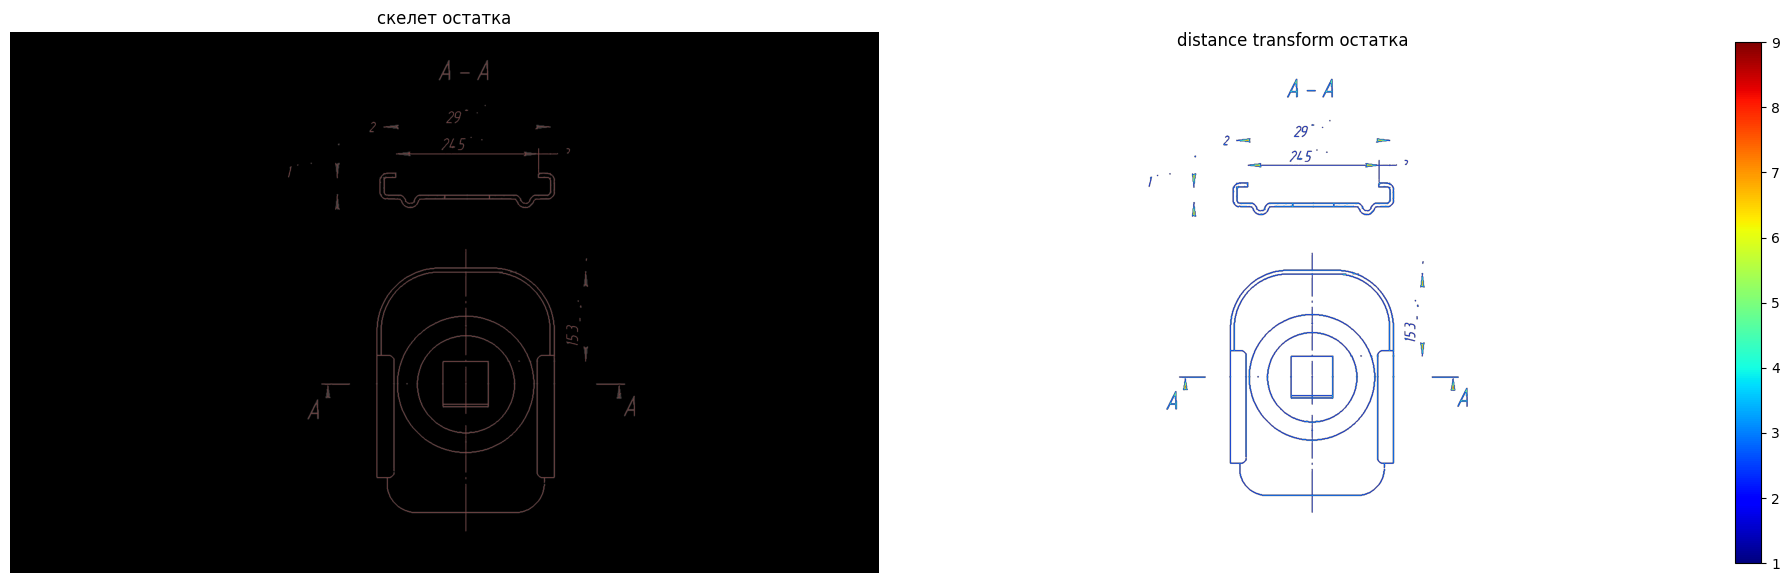

In [175]:
mask_thick = ui_thick.result

mask_thick_u8 = np.where(mask_thick, 255, 0).astype(np.uint8)
skel_t = skeletonize(mask_thick)
dist_t = cv2.distanceTransform(mask_thick_u8, cv2.DIST_L2, cv2.DIST_MASK_PRECISE)
w_med = float(np.median(dist_t[skel_t]) * 2)  # медианная ширина штриха в остатке

print(f"пикселей маски {int(mask_thick.sum())} | скелета {int(skel_t.sum())}")
print(f"ширина штриха: медиана {w_med:.1f} px | на хребте distance transform {w_med / 2:.1f}")

vis = np.zeros((*mask_thick.shape, 3), dtype=np.uint8)
vis[mask_thick] = (60, 60, 60)
vis[skel_t] = (255, 80, 80)

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
ax[0].imshow(vis)
ax[0].set_title("скелет остатка")
ax[0].axis("off")
im = ax[1].imshow(np.where(mask_thick, dist_t, np.nan), cmap="jet")
ax[1].set_title("distance transform остатка")
ax[1].axis("off")
plt.colorbar(im, ax=ax[1], fraction=0.03)
plt.tight_layout()
plt.show()

Поиск семян. `h` — выпуклость пика в долях ширины штриха, отсекает стыки и перекрестья.
`мин ширина пика` — отношение ширины в пике к ширине штриха. `мин площадь` снимает точечные пики
от зерна. Синие крестики — отвергнутое, по ним и настраивается порог.

In [176]:
_seed_cache = {}


def seeds_for(h_mult):
    """h_maxima кешируется: два других слайдера не должны его пересчитывать."""
    if h_mult not in _seed_cache:
        s = h_maxima(dist_t, h_mult * w_med / 2).astype(np.uint8)
        n, lab_s, st_s, cen = cv2.connectedComponentsWithStats(s, connectivity=8)
        rmax = np.array(ndi.maximum(dist_t, lab_s, index=np.arange(1, n))) if n > 1 else np.zeros(0)
        _seed_cache[h_mult] = (n, lab_s, st_s, cen, rmax)
    return _seed_cache[h_mult]


def find_tips(h_mult, min_ratio, min_area):
    n, lab_s, st_s, cen, rmax = seeds_for(h_mult)
    if n <= 1:
        print("ни одного пика")
        return None

    ratio = 2 * rmax / w_med
    area = st_s[1:, cv2.CC_STAT_AREA]
    ok = (ratio >= min_ratio) & (area >= min_area)

    print(f"h = {h_mult * w_med / 2:.1f} px (в радиусах) | пиков {n - 1} -> принято {int(ok.sum())}")
    if ok.any():
        print(f"принятые: ширина/штрих медиана {np.median(ratio[ok]):.2f}, площадь семени медиана {np.median(area[ok]):.0f}")

    vis = cv2.cvtColor(np.where(mask_thick, 70, 0).astype(np.uint8), cv2.COLOR_GRAY2BGR)
    for (cx, cy), r, good in zip(cen[1:], rmax, ok):
        c = (int(cx), int(cy))
        if good:
            cv2.circle(vis, c, max(int(r), 3), (255, 150, 40), 2)
        else:
            cv2.drawMarker(vis, c, (80, 140, 255), cv2.MARKER_TILTED_CROSS, 14, 1)

    fig, ax = plt.subplots(2, 1, figsize=(18, 13), height_ratios=[1, 4])
    ax[0].hist(ratio[ok], bins=40, color="orange", label="принято")
    ax[0].hist(ratio[~ok], bins=40, color="gray", alpha=0.7, label="отсеяно")
    ax[0].axvline(min_ratio, color="red", ls="--")
    ax[0].set_xlabel("ширина пика / ширина штриха")
    ax[0].legend()
    ax[0].grid(alpha=0.3)
    ax[1].imshow(vis)
    ax[1].axis("off")
    ax[1].set_title(f"h={h_mult}x, ширина>={min_ratio}, площадь>={min_area}: {int(ok.sum())} наконечников")
    plt.tight_layout()
    plt.show()

    seed_ok = np.zeros(n, dtype=bool)
    seed_ok[1:] = ok
    return seed_ok[lab_s], int(ok.sum())


ui_tips = interactive(
    find_tips,
    h_mult=FloatSlider(value=0.8, min=0.2, max=4.0, step=0.1, continuous_update=False, description="h / ширина"),
    min_ratio=FloatSlider(value=1.6, min=1.0, max=4.0, step=0.05, continuous_update=False, description="мин ширина пика"),
    min_area=IntSlider(value=1, min=1, max=200, step=1, continuous_update=False, description="мин площадь"),
)
ui_tips

interactive(children=(FloatSlider(value=0.8, continuous_update=False, description='h / ширина', max=4.0, min=0…

Удаление наконечников. Ядро — связная область, где штрих шире линии в `core_level` раз, и в
которой есть принятое семя. Снимаем ось ядра, остальное восстанавливаем по вписанным кругам —
как в шаге 7, иначе выест контур.

In [177]:
seed_px, n_tips = ui_tips.result


def remove_tips(core_level):
    core = dist_t >= core_level * w_med / 2
    n_c, lab_c = cv2.connectedComponents(core.astype(np.uint8), connectivity=8)
    hit = np.unique(lab_c[seed_px & core])
    core_ok = np.zeros(n_c, dtype=bool)
    core_ok[hit[hit > 0]] = True
    tip_core = core_ok[lab_c]

    sk_keep2 = skel_t & ~tip_core
    D2, lb2 = cv2.distanceTransformWithLabels(
        (~sk_keep2).astype(np.uint8), cv2.DIST_L2, cv2.DIST_MASK_PRECISE, labelType=cv2.DIST_LABEL_PIXEL
    )
    rad2 = np.zeros(int(lb2.max()) + 1, dtype=np.float32)
    rad2[lb2[sk_keep2]] = dist_t[sk_keep2]
    mask_clean = mask_thick & (D2 <= rad2[lb2] + 0.5)
    removed = mask_thick & ~mask_clean

    def holes(m, min_area=20):
        cnts, hier = cv2.findContours(np.where(m, 255, 0).astype(np.uint8), cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
        return 0 if hier is None else sum(1 for c, hh in zip(cnts, hier[0]) if hh[3] >= 0 and cv2.contourArea(c) >= min_area)

    cc_before = cv2.connectedComponents(mask_thick_u8, connectivity=8)[0] - 1
    cc_after = cv2.connectedComponents(np.where(mask_clean, 255, 0).astype(np.uint8), connectivity=8)[0] - 1
    print(f"семян {n_tips} | ядер задето {len(hit[hit > 0])}")
    print(f"пикселей {int(mask_thick.sum())} -> {int(mask_clean.sum())} (снято {int(removed.sum())}, {removed.sum() / mask_thick.sum() * 100:.2f}%)")
    print(f"компонент {cc_before} -> {cc_after} | замкнутых контуров {holes(mask_thick)} -> {holes(mask_clean)}")

    vis = np.zeros((*mask_thick.shape, 3), dtype=np.uint8)
    vis[mask_clean] = (255, 255, 255)
    vis[removed] = (255, 60, 60)

    fig, ax = plt.subplots(2, 1, figsize=(18, 13))
    ax[0].imshow(mask_clean, cmap="gray")
    ax[0].set_title("после удаления наконечников")
    ax[0].axis("off")
    ax[1].imshow(vis)
    ax[1].set_title("красное = снятые наконечники")
    ax[1].axis("off")
    plt.tight_layout()
    plt.show()
    return mask_clean


ui_clean = interactive(
    remove_tips,
    core_level=FloatSlider(value=1.3, min=1.0, max=3.0, step=0.05, continuous_update=False, description="ядро, x штриха"),
)
ui_clean

interactive(children=(FloatSlider(value=1.3, continuous_update=False, description='ядро, x штриха', max=3.0, m…

## Что дальше

1. **Реальные утолщения детали** (бобышки, залитые участки) проходят фильтр наконечников законно.
   Отличить можно тем, что наконечник сидит у свободного конца штриха, а утолщение — внутри контура.
2. **Текст, слитый с линией.** Если цифра касается выносной линии, они образуют одно ребро, его
   `cover` падает, и ребро уцелеет вместе с цифрой. Резервный признак на этот случай —
   «вытекание»: длина частей ребра **вне** текстовой области. У буквы она около нуля даже при
   слиянии, у линии велика.
3. **Перенос на весь датасет.** Датасет распадается на два мира: рендеры около 86 dpi и сканы
   6800–9200 px. Единый целевой размер в шаге 1 сводит их к одному масштабу, но все признаки всё
   равно нормированы на медианную ширину штриха самого изображения.